# 01_hebergements — Collecte & filtrage des hébergements

## Objectif
- Interroger **Overpass API (OSM)** pour collecter tous les hébergements le long du GR65
- Filtrer ceux situés à **moins de 1 km** de la trace
- Calculer leur **position kilométrique** sur le tracé
- Exporter un dataset utilisable pour la segmentation intelligente (notebook 01)

## Types collectés
Gîtes d'étape, refuges, hôtels, campings, chambres d'hôtes / B&B

## Entrées
- `data_raw/profile_srtm.csv` — trace GPX enrichie

## Sorties
- `data_raw/hebergements.csv` — hébergements filtrés avec position sur le tracé

> **Run All autorisé.** La requête Overpass prend ~30-60 secondes.

In [7]:
import pandas as pd
import numpy as np
import requests
import time
import json
import math
from shapely.geometry import Point, LineString
import geopandas as gpd

PROFILE_CSV   = "C:/Users/cello/Desktop/Via_Podiensis_geospatial/src/etl/data_raw/profile_srtm.csv"
OUT_HEBERGS   = "C:/Users/cello/Desktop/Via_Podiensis_geospatial/data_raw/hebergements.csv"
TOLERANCE_KM  = 1.0   # distance max à la trace
OVERPASS_URL  = "https://overpass-api.de/api/interpreter"

df = pd.read_csv(PROFILE_CSV)
print(f"Trace chargée : {len(df):,} points, {df['distance_m'].max()/1000:.1f} km")

Trace chargée : 14,765 points, 744.6 km


## 1. Construire le buffer de recherche
On extrait la bounding box de la trace pour limiter la requête Overpass.

In [8]:
# Bounding box de la trace (avec marge de 0.05°)
LAT_MIN = df["lat"].min() - 0.05
LAT_MAX = df["lat"].max() + 0.05
LON_MIN = df["lon"].min() - 0.05
LON_MAX = df["lon"].max() + 0.05

print(f"Bounding box : lat [{LAT_MIN:.3f}, {LAT_MAX:.3f}] | lon [{LON_MIN:.3f}, {LON_MAX:.3f}]")

# LineString de la trace pour calcul de distance
trace_line = LineString(zip(df["lon"], df["lat"]))
trace_gdf  = gpd.GeoDataFrame(geometry=[trace_line], crs="EPSG:4326").to_crs("EPSG:2154")  # Lambert 93
trace_proj = trace_gdf.geometry[0]

Bounding box : lat [43.110, 45.096] | lon [-1.286, 3.935]


## 2. Requête Overpass API
On cible tous les types d'hébergements pertinents pour un pèlerin.

In [9]:
# 1. On définit la zone de recherche
BBOX = f"{LAT_MIN},{LON_MIN},{LAT_MAX},{LON_MAX}"

# 2. Ta requête Overpass QL (inchangée)
query = f"""
[out:json][timeout:60];
(
  node["tourism"="hostel"]({BBOX});
  node["tourism"="guest_house"]({BBOX});
  node["tourism"="hotel"]({BBOX});
  node["tourism"="camp_site"]({BBOX});
  node["tourism"="alpine_hut"]({BBOX});
  node["amenity"="shelter"]["shelter_type"="basic_hut"]({BBOX});
  node["pilgrim_accommodation"="yes"]({BBOX});
  way["tourism"="hostel"]({BBOX});
  way["tourism"="guest_house"]({BBOX});
  way["tourism"="hotel"]({BBOX});
  way["tourism"="camp_site"]({BBOX});
);
out center;
"""

# 3. AJOUT DES HEADERS (Crucial pour éviter l'erreur 406)
headers = {
    "User-Agent": "ViaPodiensisDSProject/1.0 (celloflo@hotmail.fr)", 
    "Content-Type": "application/x-www-form-urlencoded",
    "Referer": "https://github.com/Flo4363/Via_Podiensis_geospatial"
}

print("Requête Overpass en cours...")
t0 = time.time()

# 4. EXÉCUTION (On ajoute headers=headers)
r = requests.post(OVERPASS_URL, data={"data": query}, headers=headers, timeout=90)
r.raise_for_status()

data = r.json()
print(f"Réponse reçue en {time.time()-t0:.1f}s — {len(data['elements'])} éléments bruts")

Requête Overpass en cours...
Réponse reçue en 30.0s — 5797 éléments bruts


## 3. Parser les résultats

In [10]:
TYPE_LABELS = {
    "hostel"      : "Gîte / Auberge",
    "guest_house" : "Chambre d'hôtes",
    "hotel"       : "Hôtel",
    "camp_site"   : "Camping",
    "alpine_hut"  : "Refuge",
    "shelter"     : "Abri",
}

records = []
for el in data["elements"]:
    tags = el.get("tags", {})

    # Coordonnées : node direct ou centroïde d'un way
    if el["type"] == "node":
        lat, lon = el["lat"], el["lon"]
    elif el["type"] == "way" and "center" in el:
        lat, lon = el["center"]["lat"], el["center"]["lon"]
    else:
        continue

    tourism  = tags.get("tourism", tags.get("amenity", "?"))
    type_label = TYPE_LABELS.get(tourism, tourism)

    records.append({
        "osm_id"   : el["id"],
        "nom"      : tags.get("name", "Sans nom"),
        "type"     : type_label,
        "lat"      : lat,
        "lon"      : lon,
        "phone"    : tags.get("phone", tags.get("contact:phone", "")),
        "website"  : tags.get("website", tags.get("contact:website", "")),
        "capacity" : tags.get("capacity", ""),
        "rooms"    : tags.get("rooms", ""),
    })

df_h = pd.DataFrame(records)
print(f"{len(df_h)} hébergements parsés")
df_h["type"].value_counts()

5797 hébergements parsés


type
Hôtel              2025
Camping            1587
Chambre d'hôtes    1587
Abri                315
Gîte / Auberge      273
Refuge                9
attraction            1
Name: count, dtype: int64

## 4. Filtrage à 1 km de la trace

In [11]:
# Projeter les hébergements en Lambert 93 pour calcul métrique
gdf_h = gpd.GeoDataFrame(
    df_h,
    geometry=gpd.points_from_xy(df_h["lon"], df_h["lat"]),
    crs="EPSG:4326"
).to_crs("EPSG:2154")

# Distance à la trace (en mètres)
gdf_h["dist_trace_m"] = gdf_h.geometry.distance(trace_proj)

# Filtrer à 1 km
gdf_h = gdf_h[gdf_h["dist_trace_m"] <= TOLERANCE_KM * 1000].copy()
print(f"Hébergements à moins de {TOLERANCE_KM} km de la trace : {len(gdf_h)}")
gdf_h["type"].value_counts()

Hébergements à moins de 1.0 km de la trace : 403


type
Chambre d'hôtes    151
Gîte / Auberge     105
Hôtel               92
Camping             38
Abri                17
Name: count, dtype: int64

## 5. Calculer la position kilométrique sur le tracé
Pour chaque hébergement, on trouve le point GPX le plus proche et on récupère son `distance_m`.

In [12]:
def nearest_km_on_trace(lat, lon, df_trace):
    """Retourne la distance cumulée (km) du point GPX le plus proche."""
    dists = np.sqrt(
        (df_trace["lat"] - lat) ** 2 +
        (df_trace["lon"] - lon) ** 2
    )
    idx = dists.idxmin()
    return round(df_trace.loc[idx, "distance_m"] / 1000, 2)

# Repasser en WGS84 pour récupérer lat/lon d'origine
gdf_h_wgs = gdf_h.to_crs("EPSG:4326")
gdf_h["km_sur_trace"] = [
    nearest_km_on_trace(row.geometry.y, row.geometry.x, df)
    for row in gdf_h_wgs.itertuples()
]

# Trier par position sur le tracé
gdf_h = gdf_h.sort_values("km_sur_trace").reset_index(drop=True)

print(f"Positions calculées. Aperçu :")
gdf_h[["nom", "type", "km_sur_trace", "dist_trace_m"]].head(10)

Positions calculées. Aperçu :


,nom,type,km_sur_trace,dist_trace_m
0,Ibis Styles,Hôtel,0.0,404.305396
1,Auberge de jeunesse,Gîte / Auberge,0.0,200.466607
2,Hôtel Le Regina,Hôtel,0.0,430.008340
3,Gîte Accueil Saint-François,Gîte / Auberge,0.0,104.080178
4,Hotel Saint Jacques,Hôtel,0.0,358.441999
5,Le Bilboquet,Hôtel,0.0,448.830763
6,Sans nom,Hôtel,0.0,613.626517
7,Camping de l'Accueil Saint Georges,Camping,0.0,288.071236
8,Le Jardin du Dolaizon,Chambre d'hôtes,0.0,718.157993
9,Ibis Budget,Hôtel,0.0,620.006482


## 6. Export

In [13]:
# Colonnes finales (sans géométrie Shapely)
cols = ["osm_id", "nom", "type", "lat", "lon",
        "km_sur_trace", "dist_trace_m",
        "phone", "website", "capacity", "rooms"]

df_export = gdf_h_wgs.copy()
df_export["lat"] = df_export.geometry.y
df_export["lon"] = df_export.geometry.x
df_export["km_sur_trace"]  = gdf_h["km_sur_trace"].values
df_export["dist_trace_m"]  = gdf_h["dist_trace_m"].round(0).values
df_export = df_export[cols].sort_values("km_sur_trace").reset_index(drop=True)

df_export.to_csv(OUT_HEBERGS, index=False)
print(f"Exporté : {OUT_HEBERGS}")
print(f"  {len(df_export)} hébergements | {df_export['type'].nunique()} types")
print(f"  Couverture : km {df_export['km_sur_trace'].min()} → {df_export['km_sur_trace'].max()}")

Exporté : C:/Users/cello/Desktop/Via_Podiensis_geospatial/data_raw/hebergements.csv
  403 hébergements | 5 types
  Couverture : km 0.0 → 744.56


## 7. Visualisation — répartition sur le tracé

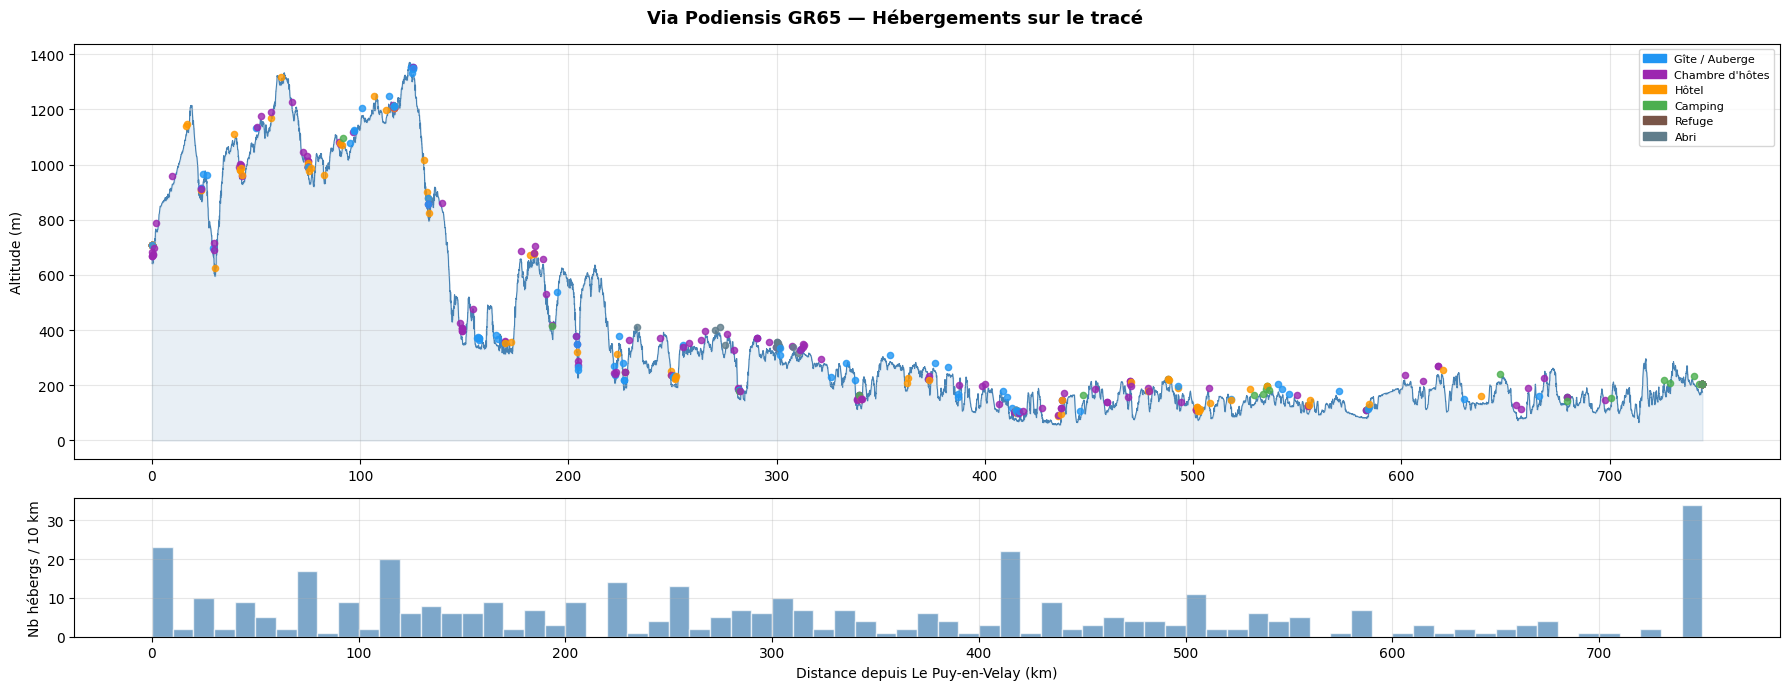

Graphique exporté : data_raw/hebergements_trace.png


In [15]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

TYPE_COLORS = {
    "Gîte / Auberge"  : "#2196F3",
    "Chambre d'hôtes" : "#9C27B0",
    "Hôtel"           : "#FF9800",
    "Camping"         : "#4CAF50",
    "Refuge"          : "#795548",
    "Abri"            : "#607D8B",
}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 7), gridspec_kw={"height_ratios": [3, 1]})
fig.suptitle("Via Podiensis GR65 — Hébergements sur le tracé", fontsize=13, fontweight="bold")

# Profil altimétrique
ax1.plot(df["distance_m"] / 1000, df["elevation"], color="steelblue", linewidth=0.8, zorder=1)
ax1.fill_between(df["distance_m"] / 1000, df["elevation"], alpha=0.12, color="steelblue")

# Points hébergements
for _, row in df_export.iterrows():
    color = TYPE_COLORS.get(row["type"], "gray")
    idx   = (df["distance_m"] / 1000 - row["km_sur_trace"]).abs().idxmin()
    alt   = df.loc[idx, "elevation"]
    ax1.scatter(row["km_sur_trace"], alt + 30, color=color, s=20, zorder=3, alpha=0.8)

ax1.set_ylabel("Altitude (m)")
ax1.grid(alpha=0.3)

# Légende
patches = [mpatches.Patch(color=c, label=t) for t, c in TYPE_COLORS.items()]
ax1.legend(handles=patches, loc="upper right", fontsize=8)

# Densité des hébergements par tranche de 10 km
bins = range(0, int(df_export["km_sur_trace"].max()) + 10, 10)
ax2.hist(df_export["km_sur_trace"], bins=bins, color="steelblue", alpha=0.7, edgecolor="white")
ax2.set_xlabel("Distance depuis Le Puy-en-Velay (km)")
ax2.set_ylabel("Nb hébergs / 10 km")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("C:/Users/cello/Desktop/Via_Podiensis_geospatial/data_raw/hebergements_trace.png", dpi=150, bbox_inches="tight")
plt.show()
print("Graphique exporté : data_raw/hebergements_trace.png")